# BAB-GJR: Conditional Betting Against Beta

**Authors:** [Andre Lopez] · [Alice Dubuis] · [Fabián Reyes Díaz]  
**Course Project**  
**Period covered:** 2000–2022  
**Training sample (IS):** 2000–2015  
**Validation sample (OOS):** 2016–2022  

**Objective (one line):** Evaluate whether conditional betas from GJR-GARCH + EWMA covariance improve BAB versus the OLS benchmark.


## 0. Setup & Data

### 0.1 Import and global parameter

In [ ]:
#%pip install arch
#%pip install wrds

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from arch import arch_model
from scipy import stats
import pandas_datareader.data as web

warnings.filterwarnings('ignore')

In [ ]:
#setup your data directory
DATA_DIR = 'data'

# Sample
DATA_START = ' 1999‑01‑01'
DATA_END = '2022-12-31'

#wrds username
WRDS_USER  = 'andrelopez'

#IS and OSS global variable

IS_END = '2015-12-31'
OOS_START = '2016-01-01'

### 0.2 Downloading market and 3FF data, Run Once or Skip

In [ ]:
#Load market index, CRSP value-weighted, save in crsp_market_daily.csv

import wrds
db = wrds.Connection(wrds_username=)
query = f'''
    SELECT caldt AS date, sprtrn AS mkt_return
    FROM crsp_a_indexes.dsix
    WHERE caldt BETWEEN '{CONSTANTS['IS_START']}' AND '{CONSTANTS['OOS_END']}'
'''
df_market_raw = pd.read_sql_query(query, db.engine)
df_market_raw.to_csv('crsp_market_daily.csv', index=False)
db.close()
print('crsp_market_daily.csv saved')

df_market_raw.head()

In [ ]:
# Load FF3 factors, save in ff_factors_monthly.csv
ff_monthly_raw = web.DataReader(
    'F-F_Research_Data_Factors',
    'famafrench',
    start=CONSTANTS['IS_START'],
    end=CONSTANTS['OOS_END']
)

df_ff3 = ff_monthly_raw[0].reset_index()
df_ff3.rename(columns={df_ff3.columns[0]: 'date'}, inplace=True)

df_ff3[['Mkt-RF','SMB','HML','RF']] /= 100
df_ff3['date'] = df_ff3['date'].dt.to_timestamp()
df_ff3['yyyymm'] = df_ff3['date'].dt.year * 100 + df_ff3['date'].dt.month

df_ff3.to_csv('ff_factors_monthly.csv', index=False)
print('ff_factors_monthly.csv saved successfully!')
df_ff3.head()

### 0.3 Downloading stock, Run Once or Skip

In [ ]:
# Load all daily return from crsp, in stocks_daily_full.csv

db = wrds.Connection(wrds_username=WRDS_USER)

out_path = os.path.join(DATA_DIR, 'stocks_daily_full.csv')

for y in range(1999, 2023):
    print("year", y)
    query = f"""
        SELECT d.permno, d.date, d.ret AS return, d.prc, d.shrout,
               n.shrcd, n.exchcd
        FROM crsp.dsf AS d
        JOIN crsp.msenames AS n
          ON d.permno = n.permno
         AND d.date BETWEEN n.namedt AND n.nameendt
        WHERE d.date BETWEEN '{y}-01-01' AND '{y}-12-31'
          AND n.shrcd IN (10, 11)
          AND n.exchcd IN (1, 2, 3)
    """
    df_y = pd.read_sql_query(query, db.engine)
    df_y.to_csv(
        out_path,
        mode='a',
        header=(y == 1999),   # header only once, in 1999
        index=False
    )
db.close()
print(f'{out_path} saved successfully!')


In [ ]:
csv_path = f'{DATA_DIR}/stocks_daily_full.csv'

df_raw = pd.read_csv(csv_path)
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw = df_raw.sort_values(['permno', 'date']).reset_index(drop=True)

print("RAW:", df_raw['date'].min(), "→", df_raw['date'].max(),
      "| rows:", len(df_raw), "stocks:", df_raw['permno'].nunique())

In [ ]:
# 1) Market cap (shrout in thousands)
df_raw['mcap']  = df_raw['prc'].abs() * df_raw['shrout']
df_raw['month'] = df_raw['date'].dt.to_period('M')

# 2) Month‑end mcap per stock
month_end_mcap = (
    df_raw.sort_values('date')
          .groupby(['permno', 'month'])
          .last()[['mcap']]
          .rename(columns={'mcap': 'mcap_monthend'})
          .reset_index()
)

# 3) Shift eligibility to next month
month_end_mcap['elig_month'] = month_end_mcap['month'] + 1


In [ ]:
# Merge previous month‑end mcap onto daily data
df_200m = df_raw.merge(
    month_end_mcap[['permno', 'elig_month', 'mcap_monthend']],
    left_on=['permno', 'month'],
    right_on=['permno', 'elig_month'],
    how='inner'
)

# Apply 200M screen (shrout in thousands → 200_000)
df_200m = df_200m[df_200m['mcap_monthend'] >= 200_000]

# Keep only from 2000‑01‑01 onward
df_200m = df_200m[df_200m['date'] >= '2000-01-01']

# Keep only permno, date, return and sort
df_200m = (
    df_200m[['permno', 'date', 'return']]
      .sort_values(['permno', 'date'])
      .reset_index(drop=True)
)

# Save
out_path = f'{DATA_DIR}/stocks_daily_200M_returns.csv'
df_200m.to_csv(out_path, index=False)
print("Saved to", out_path, "| rows:", len(df_200m), "stocks:", df_200m['permno'].nunique())


### 0.4 Data Cleaning

In [ ]:
#Load local CSVs (after running queries)

DATA_DIR = 'data'

df_stock_raw = pd.read_csv(f'{DATA_DIR}/stocks_daily_200M_returns.csv')
df_market_raw = pd.read_csv(f'{DATA_DIR}/crsp_market_daily.csv')
df_ff3 = pd.read_csv(f'{DATA_DIR}/ff_factors_monthly.csv')

print(df_stock_raw.shape, df_market_raw.shape, df_ff3.shape)


(15106090, 3) (5787, 2) (276, 6)


In [ ]:
#set index
df_stock_raw.set_index('date',inplace=True)
df_market_raw.set_index('date',inplace=True)

#check if missing value
df_stock_raw.isna().sum()
df_market_raw.isna().sum()

#sort
df_stock_raw.sort_index(inplace=True)
df_market_raw.sort_index(inplace=True)


#copy dataFrame without missing value
df_stock = df_stock_raw.dropna(subset=['return'])
df_market = df_market_raw.dropna(subset=['mkt_return'])

display(df_stock)
display(df_market)


,permno,return
date,,
2000-01-03,82515,0.014458
2000-01-03,50905,-0.003413
2000-01-03,87373,0.070707
2000-01-03,27633,-0.033248
2000-01-03,35238,-0.034965
...,...,...
2022-12-30,13967,0.029396
2022-12-30,68830,0.034752
2022-12-30,92220,0.007491


,mkt_return
date,
2000-01-03,-0.009549
2000-01-04,-0.038345
2000-01-05,0.001922
2000-01-06,0.000956
2000-01-07,0.027090
...,...
2022-12-23,0.005868
2022-12-27,-0.004050
2022-12-28,-0.012021


In [ ]:
#add columns log return
df_stock['log_ret'] = np.log1p(df_stock['return'])
df_market['log_mkt'] = np.log1p(df_market['mkt_return'])

### 0.5 Visual of data and Monthly DataFrame

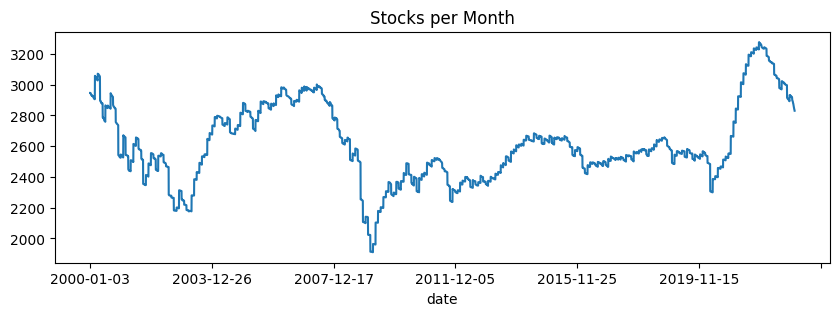

In [ ]:
#check the number of stocks per month
(df_stock.groupby('date')['permno'].nunique().plot(title='Stocks per Month',figsize=(10,3)))
plt.show()

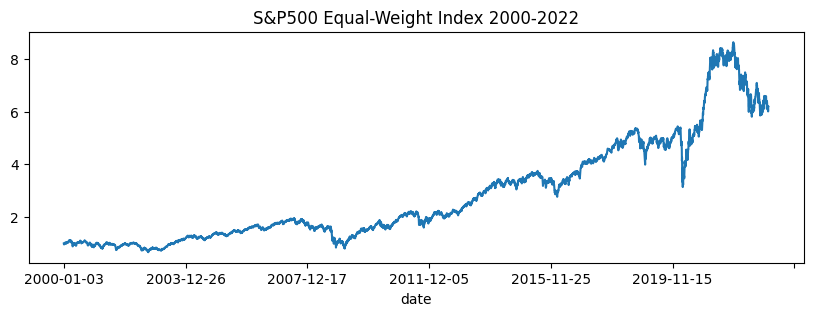

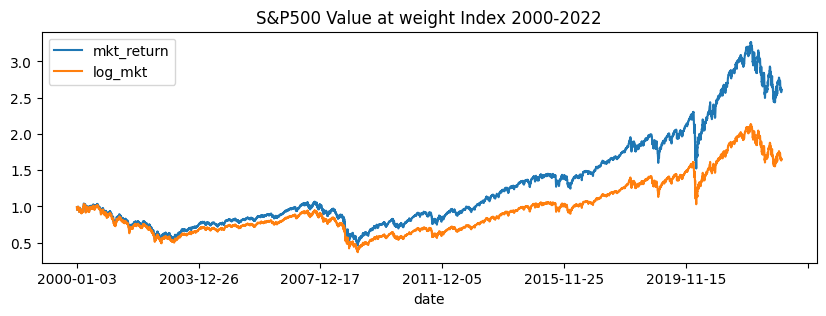

In [ ]:
# equal weight snp500 market return graph
df_stock.groupby('date')['return'].mean().add(1).cumprod().plot(title='S&P500 Equal-Weight Index 2000-2022',figsize=(10,3));
df_market.add(1).cumprod().plot(title='S&P500 Value at weight Index 2000-2022',figsize=(10,3));


In [ ]:
# Monthly DataFrame
df_stock.index = pd.to_datetime(df_stock.index)
df_market.index = pd.to_datetime(df_market.index)

# Stock DataFrame
df_stock_monthly = (
    df_stock.groupby('permno').resample('ME')
    .agg(
        ret=('return', lambda x: (1 + x).prod() - 1),
        log_ret=('log_ret', 'sum')
    )
    .reset_index().set_index('date')
)

# Market DataFrame
df_market_monthly = df_market.resample('ME').apply(lambda x: (1 + x).prod() - 1)

display(df_stock_monthly)
display(df_market_monthly)


,permno,ret,log_ret
date,,,
2004-10-31,10002,0.010639,0.010583
2004-11-30,10002,0.121051,0.114267
2004-12-31,10002,0.162036,0.150174
2005-01-31,10002,-0.132466,-0.142101
2005-02-28,10002,-0.033255,-0.033821
...,...,...,...
2022-08-31,93436,-0.072488,-0.075250
2022-09-30,93436,-0.037591,-0.038315
2022-10-31,93436,-0.142170,-0.153350


,mkt_return,log_mkt
date,,
2000-01-31,-0.050904,-0.053425
2000-02-29,-0.020107,-0.021612
2000-03-31,0.096721,0.093185
2000-04-30,-0.030795,-0.034751
2000-05-31,-0.021916,-0.024436
...,...,...
2022-08-31,-0.042439,-0.044068
2022-09-30,-0.093398,-0.095706
2022-10-31,0.079864,0.076424


Data description

## 1. BAB-OLS Beta Estimation (Frazzini & Pedersen 2014)



### 1.1 Volatility

In [ ]:
WIN_VOL  = 252
MIN_VOL  = 120

# change the DataFrame into wide to computation time
df_wide = df_stock.pivot(columns='permno', values='log_ret')

roll_vol_monthly = (
    df_wide
    .rolling(WIN_VOL, min_periods=MIN_VOL)
    .std(ddof=1)
    .resample('ME').last()
)

roll_vol_monthly = roll_vol_monthly.melt(ignore_index=False, var_name='permno', value_name='vol').reset_index().set_index('date')
display(roll_vol_monthly.head)

,permno,vol
date,,
2000-01-31,10002,NaN
2000-02-29,10002,NaN
2000-03-31,10002,NaN
2000-04-30,10002,NaN
2000-05-31,10002,NaN
...,...,...
2022-08-31,93436,0.040030
2022-09-30,93436,0.040654
2022-10-31,93436,0.041315


In [ ]:
#market volatility
mkt_vol_monthly = (
    df_market[['log_mkt']]
    .rolling(WIN_VOL, min_periods=MIN_VOL)
    .std(ddof=1)
    .resample('ME').last()
    .rename(columns={'log_mkt': 'mkt_vol'})
)

print(f"Market vol shape : {mkt_vol_monthly.shape}")
display(mkt_vol_monthly)


Market vol shape : (276, 1)


,mkt_vol
date,
2000-01-31,NaN
2000-02-29,NaN
2000-03-31,NaN
2000-04-30,NaN
2000-05-31,NaN
...,...
2022-08-31,0.013271
2022-09-30,0.013795
2022-10-31,0.014540


### 1.2 Correlation

In [ ]:
OVERLAP_WIN = 3

# stock 3-day overlapping log returns
df_wide_3d = (
    df_wide
    .rolling(OVERLAP_WIN, min_periods=OVERLAP_WIN)
    .sum()
)

# market 3-day overlapping log returns aligned to stock calendar
mkt_3d = (
    df_market['log_mkt']
    .reindex(df_wide.index)
    .rolling(OVERLAP_WIN, min_periods=OVERLAP_WIN)
    .sum()
)


In [ ]:
WIN_CORR = 1260
MIN_CORR = 750

# rolling correlation per stock vs. market on 3-day overlapping returns
roll_corr_monthly = (
    df_wide_3d
    .apply(lambda s: s.rolling(WIN_CORR, min_periods=MIN_CORR).corr(mkt_3d))
    .resample('ME').last()
)

roll_corr_monthly = (
    roll_corr_monthly
    .melt(ignore_index=False, var_name='permno', value_name='corr')
    .reset_index()
    .set_index('date')
)

#dropping the NaN and sort index
roll_corr_monthly = roll_corr_monthly.dropna(subset=['corr']).sort_index()
display(roll_corr_monthly)

,permno,corr
date,,
2002-12-31,86034,0.297599
2002-12-31,43123,0.416613
2002-12-31,77007,0.464533
2002-12-31,64515,0.508101
2002-12-31,62498,0.285822
...,...,...
2022-12-31,70033,0.580047
2022-12-31,17778,0.778283
2022-12-31,89626,0.551358


### 1.3 shrinkage toward 1 (Frazzini & Pedersen 2014)
Beta = ρ × (σᵢ / σₘ)

In [ ]:
SHRINK = 0.6   # weight on raw beta (0.4 toward prior of 1)

# merge stock vol + corr on (date, permno), then bring in market vol on date
df_beta = (
    roll_vol_monthly
    .merge(roll_corr_monthly, on=['date', 'permno'], how='inner')
    .merge(mkt_vol_monthly, on='date', how='left')
)

# raw beta
df_beta['beta_raw'] = df_beta['corr'] * (df_beta['vol'] / df_beta['mkt_vol'])

# shrink toward 1: β = 0.6 × β_raw + 0.4
df_beta['beta'] = SHRINK * df_beta['beta_raw'] + (1 - SHRINK)

# drop rows where beta couldn't be computed (insufficient history)
df_beta = df_beta.dropna(subset=['beta']).sort_index()

print("NaN corr:", df_beta['corr'].isna().sum())

#display(df_beta)
print(f"Shape: {df_beta.shape}")
print(f"Beta_raw stats:\n{df_beta['beta_raw'].describe().round(3)}")
print(f"Beta stats:\n{df_beta['beta'].describe().round(3)}")


non-NaN corr: 0
Shape: (499187, 6)
Beta_raw stats:
count    499187.000
mean          1.183
std           0.517
min          -1.094
25%           0.828
50%           1.110
75%           1.449
max           9.040
Name: beta_raw, dtype: float64
Beta stats:
count    499187.000
mean          1.110
std           0.310
min          -0.256
25%           0.897
50%           1.066
75%           1.270
max           5.824
Name: beta, dtype: float64


### 1.4 BAB Portfolio Construction

In [ ]:
#Construct the Fonction for the BAB strategy, use for OLS and GARCH

def build_bab_from_beta(df_beta, df_stock_monthly, df_ff3):
    '''
    Build monthly BAB returns from monthly stock betas.

    Inputs:
    - df_beta         : monthly betas by (date, permno), with column 'beta'
    - df_stock_monthly: monthly returns by (date, permno), with column 'ret'
    - df_ff3          : monthly risk-free rate, columns ['yyyymm', 'RF']

    Output: monthly BAB table with r_long, r_short, beta_long, beta_short,
            n_stocks, yyyymm, RF, r_bab.
    '''
    df_beta_lagged = (
        df_beta[['permno', 'beta']]
        .reset_index()
        .assign(date=lambda x: x['date'] + pd.offsets.MonthEnd(1))
    )
    df_bab_input = (
        df_beta_lagged
        .merge(
            df_stock_monthly[['permno', 'ret']].reset_index(),
            on=['date', 'permno'],
            how='inner'
        )
        .dropna(subset=['ret', 'beta'])
    )
    def assign_bab_weights(group):
        z = group['beta'].rank() / (len(group) + 1)
        z = z - z.median()
        long_w  = (-z).clip(lower=0)
        short_w = z.clip(lower=0)
        group['w_long']  = long_w  / long_w.sum()
        group['w_short'] = short_w / short_w.sum()
        return group

    df_bab_input = df_bab_input.groupby('date', group_keys=False).apply(assign_bab_weights)

    df_bab_monthly = (
        df_bab_input
        .groupby('date')
        .apply(lambda g: pd.Series({
            'r_long':     (g['w_long']  * g['ret']).sum(),
            'r_short':    (g['w_short'] * g['ret']).sum(),
            'beta_long':  (g['w_long']  * g['beta']).sum(),
            'beta_short': (g['w_short'] * g['beta']).sum(),
            'n_stocks':   len(g)
        }))
    )
    df_bab_monthly['yyyymm'] = df_bab_monthly.index.year * 100 + df_bab_monthly.index.month
    df_bab_monthly = df_bab_monthly.merge(df_ff3[['yyyymm', 'RF']], on='yyyymm', how='left')
    df_bab_monthly['r_bab'] = (
          (1 / df_bab_monthly['beta_long'])  * (df_bab_monthly['r_long']  - df_bab_monthly['RF'])
        - (1 / df_bab_monthly['beta_short']) * (df_bab_monthly['r_short'] - df_bab_monthly['RF'])
    )
    return df_bab_monthly, df_bab_input



In [ ]:
# OLS-BAB
df_bab_monthly_ols, df_bab_weights_ols = build_bab_from_beta(df_beta, df_stock_monthly, df_ff3)
#display(df_bab_monthly_ols)

### 1.5 OLS-BAB Performance Analysis

In [ ]:
def calculate_bab_leverage(df_bab_monthly, print_stats=True):
    '''
    Calculates and summarizes the leverage and month-over-month leverage
    change for a Betting Against Beta portfolio.

    Inputs:
    - df_bab_monthly: Portfolio-level returns (must contain 'beta_long', 'beta_short')

    Output: Pandas DataFrame containing the statistical summary table.
    '''

    df_leverage = pd.DataFrame(index=df_bab_monthly.index)

    # 1. Calculate explicit Leverage for Long and Short legs
    df_leverage['Long Leverage (1/β_L)'] = 1 / df_bab_monthly['beta_long']
    df_leverage['Short Leverage (1/β_H)'] = 1 / df_bab_monthly['beta_short']

    # 2. Calculate "how much it changes" (Month-over-Month Absolute Change)
    df_leverage['Long Δ (Abs Change)']  = df_leverage['Long Leverage (1/β_L)'].diff().abs()
    df_leverage['Short Δ (Abs Change)'] = df_leverage['Short Leverage (1/β_H)'].diff().abs()

    # 3. Create a clean statistical summary table
    leverage_stats = df_leverage.describe().T[['mean', 'std', 'min', '50%', 'max']]
    leverage_stats.columns = ['Mean', 'Volatility', 'Min', 'Median', 'Max']

    if print_stats:
        display(leverage_stats.round(3))

    return leverage_stats


In [ ]:
lev_stats_ols = calculate_bab_leverage(df_bab_monthly_ols)

,Mean,Volatility,Min,Median,Max
Long Leverage (1/β_L),1.208,0.149,0.883,1.195,1.614
Short Leverage (1/β_H),0.712,0.088,0.516,0.702,0.906
Long Δ (Abs Change),0.018,0.023,0.000,0.010,0.185
Short Δ (Abs Change),0.015,0.020,0.000,0.008,0.154


In [ ]:
def calculate_bab_turnover(df_bab_weights, df_bab_monthly, print_stats=True):
    '''
    Calculates the monthly turnover for a Betting Against Beta portfolio.

    Inputs:
    - df_bab_weights: Stock-level weights (must contain 'date', 'permno', 'w_long', 'w_short')
    - df_bab_monthly: Portfolio-level returns (must contain 'yyyymm', 'beta_long', 'beta_short')

    Output: Pandas Series containing the total portfolio turnover for each month.
    '''
    # 1. Ensure 'yyyymm' exists in the weights dataframe for a safe merge
    df_weights = df_bab_weights.copy()
    if 'yyyymm' not in df_weights.columns:
        df_weights['yyyymm'] = df_weights['date'].dt.year * 100 + df_weights['date'].dt.month
    # 2. Merge portfolio betas into the stock-level data
    df_turnover_calc = df_weights.merge(
        df_bab_monthly[['yyyymm', 'beta_long', 'beta_short']],
        on='yyyymm',
        how='left'
    )
    # 3. Calculate the FINAL active BAB weight for each stock
    df_turnover_calc['w_bab'] = (
        (1 / df_turnover_calc['beta_long'])  * df_turnover_calc['w_long']
      - (1 / df_turnover_calc['beta_short']) * df_turnover_calc['w_short']
    )
    # 4. Pivot so Dates are rows and stocks are columns
    df_weights_wide = df_turnover_calc.pivot_table(
        index='date',
        columns='permno',
        values='w_bab'
    ).fillna(0)
    # 5. Calculate Turnover (Sum of absolute changes month-over-month)
    turnover_monthly = df_weights_wide.diff().abs().sum(axis=1)

    if print_stats:
        print(f"Average Monthly Turnover    : {turnover_monthly.mean():.2%}")
        print(f"Average Annualized Turnover : {turnover_monthly.mean() * 12:.2%}")
    return turnover_monthly

In [ ]:
turnover_ols = calculate_bab_turnover(df_bab_weights_ols, df_bab_monthly_ols)

Average Monthly Turnover    : 23.19%
Average Annualized Turnover : 278.31%


In [ ]:
FEE_RATE = 0.0005

def compute_net_returns(df_bab_monthly, df_bab_weights, fee_rate=FEE_RATE):

    # pivot to (date × permno) matrices; missing stock in a month = weight of 0
    w_long  = df_bab_weights.pivot_table(index='date', columns='permno', values='w_long',  aggfunc='first').fillna(0)
    w_short = df_bab_weights.pivot_table(index='date', columns='permno', values='w_short', aggfunc='first').fillna(0)

    # absolute weight change per month summed across all stocks = portfolio turnover
    monthly_tc = fee_rate * (w_long.diff().abs().sum(axis=1) + w_short.diff().abs().sum(axis=1))
    monthly_tc = monthly_tc.rename_axis('date').reset_index(name='tc')
    monthly_tc['yyyymm'] = monthly_tc['date'].dt.year * 100 + monthly_tc['date'].dt.month

    df_net = df_bab_monthly.copy()
    df_net = df_net.merge(monthly_tc[['yyyymm', 'tc']], on='yyyymm', how='left')
    df_net['r_bab_net'] = df_net['r_bab'] - df_net['tc'].fillna(0)
    return df_net

In [ ]:
# apply to OLS
df_bab_monthly_ols = compute_net_returns(df_bab_monthly_ols, df_bab_weights_ols)
print(f"OLS  avg monthly TC : {df_bab_monthly_ols['tc'].mean():.4f}  ({df_bab_monthly_ols['tc'].mean()*12:.4f} ann.)")
print(f"OLS  gross Sharpe   : {df_bab_monthly_ols['r_bab'].mean()*12 / (df_bab_monthly_ols['r_bab'].std()*np.sqrt(12)):.2f}")
print(f"OLS  net   Sharpe   : {df_bab_monthly_ols['r_bab_net'].mean()*12 / (df_bab_monthly_ols['r_bab_net'].std()*np.sqrt(12)):.2f}")

OLS  avg monthly TC : 0.0001  (0.0014 ann.)
OLS  gross Sharpe   : 0.55
OLS  net   Sharpe   : 0.53


In [ ]:
IS_END    = '2015-12-31'
OOS_START = '2016-01-01'

# ensure date index and reset index
df_bab_monthly_ols['date'] = pd.to_datetime(df_bab_monthly_ols['yyyymm'].astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
df_bab_monthly_ols = df_bab_monthly_ols.set_index('date').sort_index()

#Spliting the DataFrame IS/OSS
df_is  = df_bab_monthly_ols[df_bab_monthly_ols.index <= IS_END]
df_oos = df_bab_monthly_ols[df_bab_monthly_ols.index >= OOS_START]


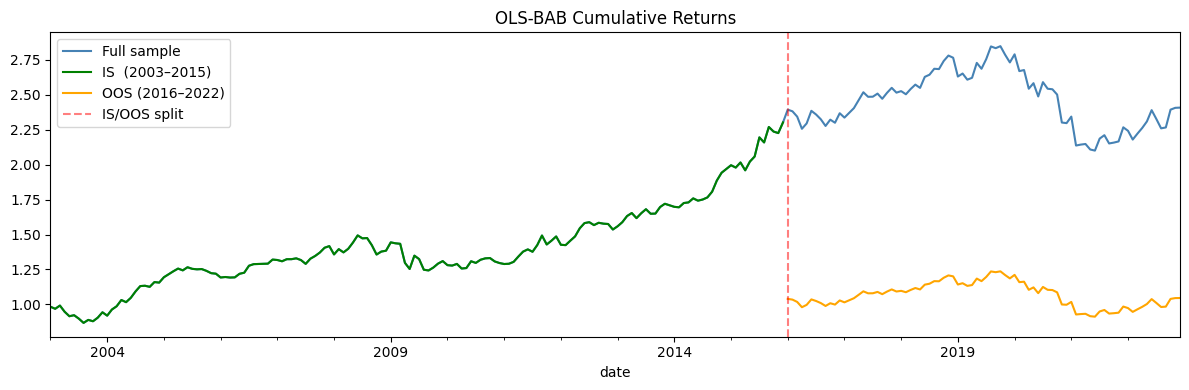

In [ ]:

# Ploting cumulative return

fig, ax = plt.subplots(figsize=(12, 4))
(1 + df_bab_monthly_ols['r_bab']).cumprod().plot(ax=ax, label='Full sample', color='steelblue')
(1 + df_is['r_bab']).cumprod().plot(ax=ax, label=f'IS  (2003–2015)', color='green')
(1 + df_oos['r_bab']).cumprod().plot(ax=ax, label=f'OOS (2016–2022)', color='orange')
ax.axvline(pd.Timestamp(OOS_START), color='red', linestyle='--', alpha=0.5, label='IS/OOS split')
ax.set_title('OLS-BAB Cumulative Returns')
ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
# Performance metrics table
def perf_metrics(returns, label):
    ann_ret = returns.mean() * 12
    ann_vol = returns.std()  * np.sqrt(12)
    sharpe  = ann_ret / ann_vol
    print(f"\n{label}")
    print(f"  Ann. Return : {ann_ret:.2%}")
    print(f"  Ann. Vol    : {ann_vol:.2%}")
    print(f"  Sharpe      : {sharpe:.2f}")

for subset, label in [(df_bab_monthly_ols, 'Full Sample'),
                      (df_is,          'IS  (2003–2015)'),
                      (df_oos,         'OOS (2016–2022)')]:
    perf_metrics(subset['r_bab'], label)


Full Sample
  Ann. Return : 4.78%
  Ann. Vol    : 8.70%
  Sharpe      : 0.55

IS  (2003–2015)
  Ann. Return : 6.79%
  Ann. Vol    : 8.50%
  Sharpe      : 0.80

OOS (2016–2022)
  Ann. Return : 1.05%
  Ann. Vol    : 9.00%
  Sharpe      : 0.12


In [ ]:
# CAPM & FF3 alpha
def reg_alpha(df, label):
    capm = smf.ols('r_bab ~ Q("Mkt-RF")',                  data=df).fit()
    ff3  = smf.ols('r_bab ~ Q("Mkt-RF") + SMB + HML',     data=df).fit()
    print(f"\n{label}")
    print(f"  CAPM alpha : {capm.params['Intercept']:.4f}  (t = {capm.tvalues['Intercept']:.2f})")
    print(f"  FF3  alpha : {ff3.params['Intercept']:.4f}  (t = {ff3.tvalues['Intercept']:.2f})")

for subset, label in [(df_bab_monthly_ols, 'Full Sample'),
                      (df_is,          'IS  (2003–2015)'),
                      (df_oos,         'OOS (2016–2022)')]:
    reg_alpha(subset.merge(df_ff3[['yyyymm','Mkt-RF','SMB','HML']], on='yyyymm', how='left'), label)



Full Sample
  CAPM alpha : 0.0050  (t = 3.10)
  FF3  alpha : 0.0048  (t = 3.16)

IS  (2003–2015)
  CAPM alpha : 0.0066  (t = 3.36)
  FF3  alpha : 0.0063  (t = 3.47)

OOS (2016–2022)
  CAPM alpha : 0.0020  (t = 0.72)
  FF3  alpha : 0.0014  (t = 0.52)


## 2 Conditional Estimator: BAB-GJR (main contribution)

Prepare market returns, scaling by 100 for numerical stability — GARCH optimizers
work better with numbers around 1 than numbers around 0.01

In [ ]:
mkt_scaled = df_market['log_mkt'] * 100
mkt_scaled_is = mkt_scaled.loc[:'2015-12-31']   # IS only for estimation

Calculation of GJR-GARCH parameter on IS only

This finds the best ω, α, γ, β that describe market volatility - These parameters are then FROZEN

Student-t distribution captures fat tails in stock returns.

In [ ]:

res_mkt = arch_model(
    mkt_scaled_is,
    vol='Garch', p=1, o=1, q=1,
    dist='t',
    rescale=False
).fit(disp='off')

print(res_mkt.summary())

                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                      log_mkt   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -5615.95
Distribution:      Standardized Student's t   AIC:                           11243.9
Method:                  Maximum Likelihood   BIC:                           11281.7
                                              No. Observations:                 4025
Date:                      Wed, Mar 25 2026   Df Residuals:                     4024
Time:                              19:38:54   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
m

Extract and verify parameters

Persistence = alpha + gamma/2 + beta must be < 1 ,otherwise volatility explodes to infinity over time.

gamma should be significant — this is the whole point of GJR,

it captures that bad news increases volatility more than good news.

In [ ]:

mu_m  = res_mkt.params['mu']
omega = res_mkt.params['omega']
alpha = res_mkt.params['alpha[1]']
gamma = res_mkt.params['gamma[1]']
beta  = res_mkt.params['beta[1]']

persistence = alpha + gamma/2 + beta
print(f"\nParameters:")
print(f"  mu    = {mu_m:.4f}")
print(f"  omega = {omega:.4f}")
print(f"  alpha = {alpha:.4f}")
print(f"  gamma = {gamma:.4f}  (p = {res_mkt.pvalues['gamma[1]']:.4f})")
print(f"  beta  = {beta:.4f}")
print(f"\nPersistence (alpha + gamma/2 + beta) = {persistence:.4f}")



Parameters:
  mu    = 0.0249
  omega = 0.0163
  alpha = 0.0000
  gamma = 0.1744  (p = 0.0000)
  beta  = 0.8990

Persistence (alpha + gamma/2 + beta) = 0.9862


Recursive filtering on full period (IS + OOS)

Now we use the FROZEN parameters to compute daily volatility for every day 2000-2022.

We cannot use res_mkt.conditional_volatility here because
that only covers IS. We manually run the recursion forward.

The recursion is:
σ²_t = ω + (α + γ·1[ε<0]) · ε²_{t-1} + β · σ²_{t-1}

Initialization: unconditional variance = ω / (1 - α - γ/2 - β)
This is the long-run average variance implied by the model.

In [ ]:


uncond_var = omega / (1 - persistence)
eps        = (mkt_scaled - mu_m).values       # residuals for full period
sigma2     = np.full(len(eps), uncond_var)    # pre-fill with unconditional var

for t in range(1, len(eps)):
    leverage   = gamma if eps[t-1] < 0 else 0.0
    sigma2[t]  = omega + (alpha + leverage) * eps[t-1]**2 + beta * sigma2[t-1]

# convert back to original scale (divide by 100) and store as daily series
gjr_mkt_vol = pd.Series(
    np.sqrt(sigma2) / 100,
    index=mkt_scaled.index,
    name='gjr_mkt_vol'
)

# also store variance (needed later for beta computation)
gjr_mkt_var = pd.Series(
    sigma2 / 100**2,
    index=mkt_scaled.index,
    name='gjr_mkt_var')

count    5787.0000
mean        0.0108
std         0.0067
min         0.0043
25%         0.0066
50%         0.0090
75%         0.0130
max         0.0750
dtype: float64


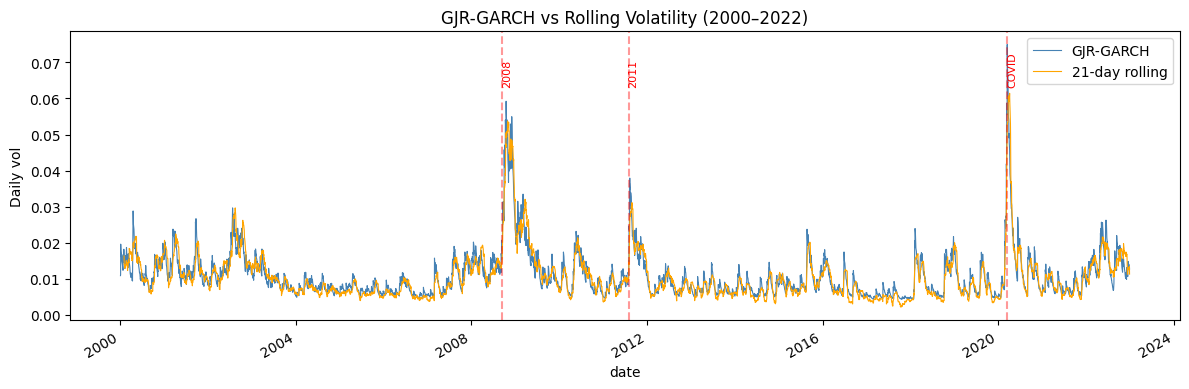

In [ ]:
# Sanity check — GJR vol vs rolling vol with crisis annotations
gjr_vol     = pd.Series(np.sqrt(sigma2) / 100, index=mkt_scaled.index)
rolling_vol = (mkt_scaled / 100).rolling(21).std()

# quick stats
print(gjr_vol.describe().round(4))

# plot
fig, ax = plt.subplots(figsize=(12, 4))
gjr_vol.plot(ax=ax,     label='GJR-GARCH',     color='steelblue', linewidth=0.8)
rolling_vol.plot(ax=ax, label='21-day rolling', color='orange',   linewidth=0.8)

for date, label in [('2008-09-15', '2008'),
                    ('2011-08-01', '2011'),
                    ('2020-03-16', 'COVID')]:
    ax.axvline(pd.Timestamp(date), color='red', linestyle='--', alpha=0.4)
    ax.text(pd.Timestamp(date), gjr_vol.max() * 0.85, label,
            rotation=90, fontsize=8, color='red')

ax.set_title('GJR-GARCH vs Rolling Volatility (2000–2022)')
ax.set_ylabel('Daily vol')
ax.legend()
plt.tight_layout()
plt.show()

### 2.2 — EWMA Covariance & Conditional Betas
Goal: compute beta_cond for every stock every month
 using EWMA covariance and GJR market variance

In [ ]:
# Stock residual: actual daily return (mean assumed 0) and Market residual: actual daily return minus GJR mean (mu_m)

eps_m = (df_market['log_mkt'] - mu_m / 100).reindex(df_wide.index)

EWMA covariance recursion per stock

For each stock, run daily loop:

Cov_t = lambda * Cov_{t-1} + (1 - lambda) * eps_i_t * eps_m_t

Initialization: sample covariance over first EWMA_INIT_DAYS days

In [ ]:
LAMBDA         = 0.94
EWMA_INIT_DAYS = 125

def ewma_cov_stock(eps_i, eps_m, lam, init_days):
    """
    Compute EWMA covariance between stock i and market.
    eps_i:    daily residuals for one stock (pandas Series, daily)
    eps_m:    daily market residuals (pandas Series, daily)
    lam:      decay factor (0.94)
    init_days: number of days used to initialize covariance
    """
    # align both series to same dates, drop NaNs
    df = pd.DataFrame({'eps_i': eps_i, 'eps_m': eps_m}).dropna()
    n   = len(df)
    cov = np.full(n, np.nan)

    if n < init_days:
        return pd.Series(cov, index=df.index)

    # initialization: sample covariance over first init_days
    cov[init_days - 1] = (
        df['eps_i'].iloc[:init_days].values *
        df['eps_m'].iloc[:init_days].values
    ).mean()

    # recursion from init_days onwards
    for t in range(init_days, n):
        cov[t] = (
            lam * cov[t-1] +
            (1 - lam) * df['eps_i'].iloc[t] * df['eps_m'].iloc[t]
        )

    return pd.Series(cov, index=df.index, name=eps_i.name)


# run for all stocks
print("Computing EWMA covariances...")
ewma_cov_dict = {}

for i, permno in enumerate(df_wide.columns):
    if i % 100 == 0:
        print(f"  {i}/{df_wide.shape[1]} stocks...")
    eps_i = df_wide[permno]
    ewma_cov_dict[permno] = ewma_cov_stock(eps_i, eps_m, LAMBDA, EWMA_INIT_DAYS)

df_ewma_cov = pd.DataFrame(ewma_cov_dict)
print(f"\nEWMA covariance matrix shape: {df_ewma_cov.shape}")

Computing EWMA covariances...
  0/8812 stocks...
  100/8812 stocks...
  200/8812 stocks...
  300/8812 stocks...
  400/8812 stocks...
  500/8812 stocks...
  600/8812 stocks...
  700/8812 stocks...
  800/8812 stocks...
  900/8812 stocks...
  1000/8812 stocks...
  1100/8812 stocks...
  1200/8812 stocks...
  1300/8812 stocks...
  1400/8812 stocks...
  1500/8812 stocks...
  1600/8812 stocks...
  1700/8812 stocks...
  1800/8812 stocks...
  1900/8812 stocks...
  2000/8812 stocks...
  2100/8812 stocks...
  2200/8812 stocks...
  2300/8812 stocks...
  2400/8812 stocks...
  2500/8812 stocks...
  2600/8812 stocks...
  2700/8812 stocks...
  2800/8812 stocks...
  2900/8812 stocks...
  3000/8812 stocks...
  3100/8812 stocks...
  3200/8812 stocks...
  3300/8812 stocks...
  3400/8812 stocks...
  3500/8812 stocks...
  3600/8812 stocks...
  3700/8812 stocks...
  3800/8812 stocks...
  3900/8812 stocks...
  4000/8812 stocks...
  4100/8812 stocks...
  4200/8812 stocks...
  4300/8812 stocks...
  4400/8812 st

In [ ]:
#Extract month-end values and compute conditional beta: beta_cond = EWMA_cov / GJR_market_var  at each month-end
gjr_mkt_var_monthly  = gjr_mkt_var.resample('ME').last()
df_ewma_cov_monthly  = df_ewma_cov.resample('ME').last()

# conditional beta = cov / var at month-end
df_beta_cond = df_ewma_cov_monthly.divide(gjr_mkt_var_monthly, axis=0)


Reshape and merge into df_monthly

In [ ]:
# build df_monthly (unified table: ret + RF + beta_ols)
df_monthly = (
    df_stock_monthly[['permno', 'ret']]
    .reset_index()
    .assign(yyyymm=lambda x: x['date'].dt.year * 100 + x['date'].dt.month)
    .merge(df_ff3[['yyyymm', 'RF']], on='yyyymm', how='left')
    .merge(
        df_beta[['permno', 'beta']].rename(columns={'beta': 'beta_ols'}).reset_index(),
        on=['date', 'permno'],
        how='left'
    )
)

# melt beta_cond to long format and add yyyymm key
df_beta_cond_long = (
    df_beta_cond
    .melt(ignore_index=False, var_name='permno', value_name='beta_cond')
    .reset_index()
)
df_beta_cond_long['yyyymm'] = (
    df_beta_cond_long['date'].dt.year * 100 +
    df_beta_cond_long['date'].dt.month
)

# merge beta_cond into df_monthly
df_monthly = df_monthly.merge(
    df_beta_cond_long[['yyyymm', 'permno', 'beta_cond']],
    on=['yyyymm', 'permno'],
    how='left'
)

# clip to (0.1, 3.0) — negative betas stocks are noise
df_monthly['beta_cond'] = df_monthly['beta_cond'].clip(0.1, 3.0)

# same Vasicek shrinkage as OLS — necessary for fair comparison
df_monthly['beta_cond'] = SHRINK * df_monthly['beta_cond'] + (1 - SHRINK)

In [ ]:
#Sanity check

print(f"\nbeta_cond stats:")
print(df_monthly['beta_cond'].describe().round(3))
print(f"\nbeta_ols stats:")
print(df_monthly['beta_ols'].describe().round(3))
print(f"\nCorrelation between beta_ols and beta_cond:")
print(df_monthly[['beta_ols', 'beta_cond']].corr().round(3))



beta_cond stats:
count    678078.000
mean          1.088
std           0.443
min           0.460
25%           0.765
50%           0.998
75%           1.322
max           2.200
Name: beta_cond, dtype: float64

beta_ols stats:
count    484326.000
mean          1.110
std           0.305
min          -0.256
25%           0.899
50%           1.066
75%           1.268
max           5.296
Name: beta_ols, dtype: float64

Correlation between beta_ols and beta_cond:
           beta_ols  beta_cond
beta_ols      1.000      0.306
beta_cond     0.306      1.000


### 2.3 BAB-GJR Portfolio Construction

In [ ]:
## BAB-GJR Portfolio Construction

LEVERAGE_CAP = 1.5
MIN_BETA     = 1 / LEVERAGE_CAP   # = 0.5  →  max leverage = 2x

# Prepare GJR betas
df_beta_gjr_input = (
    df_monthly[['date', 'permno', 'beta_cond']]
    .rename(columns={'beta_cond': 'beta'})
    .set_index('date')
    .dropna(subset=['beta'])
)
df_beta_gjr_input['beta'] = df_beta_gjr_input['beta'].clip(lower=MIN_BETA)

# Build BAB-GJR
df_bab_monthly_gjr, df_bab_weights_gjr = build_bab_from_beta(df_beta_gjr_input, df_stock_monthly, df_ff3)


Clip portfolio-level betas and recompute r_bab

Some months produce beta_long/beta_short = 0 (all-NaN weights → pandas .sum() = 0 → 1/0 = inf)

Clipping the columns fixes both r_bab and the downstream diagnostic functions

In [ ]:
df_bab_monthly_gjr[['beta_long', 'beta_short']] = (
    df_bab_monthly_gjr[['beta_long', 'beta_short']].clip(lower=MIN_BETA)
)

df_bab_monthly_gjr['r_bab'] = (
      (1 / df_bab_monthly_gjr['beta_long']) * (df_bab_monthly_gjr['r_long']  - df_bab_monthly_gjr['RF'])
    - (1 / df_bab_monthly_gjr['beta_short']) * (df_bab_monthly_gjr['r_short'] - df_bab_monthly_gjr['RF'])
)

In [ ]:
# Transaction costs, calling the fonction
df_bab_monthly_gjr = compute_net_returns(df_bab_monthly_gjr, df_bab_weights_gjr)
print(f"GJR  avg monthly TC : {df_bab_monthly_gjr['tc'].mean():.4f}  ({df_bab_monthly_gjr['tc'].mean()*12:.4f} ann.)")
print(f"GJR  gross Sharpe   : {df_bab_monthly_gjr['r_bab'].mean()*12 / (df_bab_monthly_gjr['r_bab'].std()*np.sqrt(12)):.2f}")

GJR  avg monthly TC : 0.0007  (0.0088 ann.)
GJR  gross Sharpe   : 0.79


In [ ]:
# Leverage stats & turnover
lev_stats_gjr = calculate_bab_leverage(df_bab_monthly_gjr)
turnover_gjr  = calculate_bab_turnover(df_bab_weights_gjr, df_bab_monthly_gjr)

display(df_bab_monthly_gjr.head())
print(f"\nBAB-GJR r_bab stats:\n{df_bab_monthly_gjr['r_bab'].describe().round(4)}")

,Mean,Volatility,Min,Median,Max
Long Leverage (1/β_L),1.306,0.174,0.649,1.354,1.500
Short Leverage (1/β_H),0.702,0.167,0.456,0.684,1.500
Long Δ (Abs Change),0.143,0.120,0.000,0.118,0.604
Short Δ (Abs Change),0.164,0.141,0.001,0.134,1.032


Average Monthly Turnover    : 155.69%
Average Annualized Turnover : 1868.29%


,r_long,r_short,beta_long,beta_short,n_stocks,yyyymm,RF,r_bab,tc,r_bab_net
0,0.021767,-0.083652,0.783790,2.024816,2439.0,200007,0.0048,0.065331,0.000000,0.065331
1,0.054010,0.121615,0.667873,1.366788,2451.0,200008,0.0050,-0.011939,0.000656,-0.012594
2,-0.021959,-0.082338,0.695841,1.862408,2541.0,200009,0.0051,0.008062,0.000743,0.007319
3,-0.022365,-0.090813,0.683695,1.912847,2551.0,200010,0.0056,0.009500,0.000931,0.008569
4,-0.014846,-0.250792,0.693038,1.828696,2514.0,200011,0.0051,0.111152,0.000827,0.110324



BAB-GJR r_bab stats:
count    270.0000
mean       0.0096
std        0.0421
min       -0.1094
25%       -0.0077
50%        0.0092
75%        0.0226
max        0.3768
Name: r_bab, dtype: float64


### 2.4 BAB-GJR Performance Analysis

In [ ]:
# Date index & IS/OOS split
df_bab_monthly_gjr['date'] = (
    pd.to_datetime(df_bab_monthly_gjr['yyyymm'].astype(str), format='%Y%m')
    + pd.offsets.MonthEnd(0)
)
df_bab_monthly_gjr = df_bab_monthly_gjr.set_index('date').sort_index()

df_is_gjr  = df_bab_monthly_gjr[df_bab_monthly_gjr.index <= IS_END]
df_oos_gjr = df_bab_monthly_gjr[df_bab_monthly_gjr.index >= OOS_START]

print(f"GJR full: {len(df_bab_monthly_gjr)} months  |  IS: {len(df_is_gjr)}  |  OOS: {len(df_oos_gjr)}")

GJR full: 270 months  |  IS: 186  |  OOS: 84


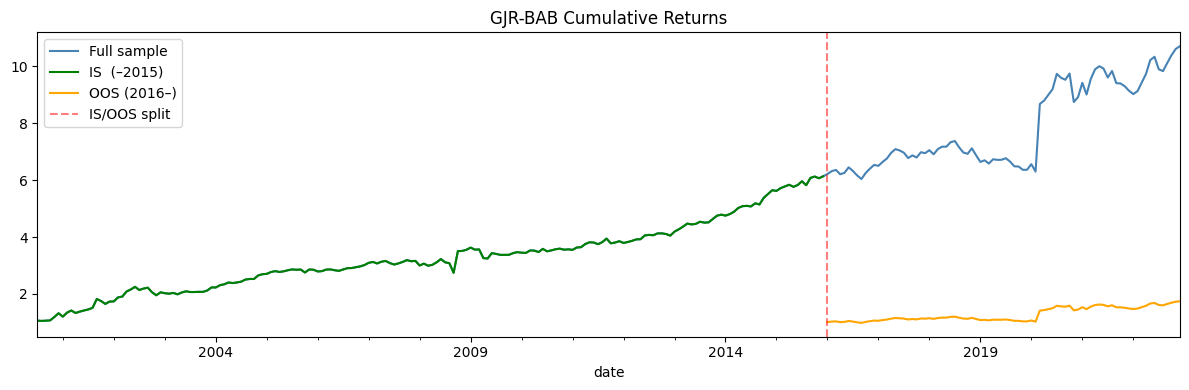

In [ ]:
# Cumulative return plot
fig, ax = plt.subplots(figsize=(12, 4))
(1 + df_bab_monthly_gjr['r_bab']).cumprod().plot(ax=ax, label='Full sample', color='steelblue')
(1 + df_is_gjr['r_bab']).cumprod().plot(ax=ax, label='IS  (–2015)', color='green')
(1 + df_oos_gjr['r_bab']).cumprod().plot(ax=ax, label='OOS (2016–)', color='orange')
ax.axvline(pd.Timestamp(OOS_START), color='red', linestyle='--', alpha=0.5, label='IS/OOS split')
ax.set_title('GJR-BAB Cumulative Returns')
ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
# Performance metric
for subset, label in [(df_bab_monthly_gjr, 'Full Sample'),
                      (df_is_gjr,          'IS  (–2015)'),
                      (df_oos_gjr,         'OOS (2016–)')]:
    perf_metrics(subset['r_bab'].dropna(), label)


Full Sample
  Ann. Return : 11.55%
  Ann. Vol    : 14.60%
  Sharpe      : 0.79

IS  (–2015)
  Ann. Return : 12.61%
  Ann. Vol    : 13.47%
  Sharpe      : 0.94

OOS (2016–)
  Ann. Return : 9.20%
  Ann. Vol    : 16.90%
  Sharpe      : 0.54


In [ ]:
# CAPM & FF3 alpha
for subset, label in [(df_bab_monthly_gjr, 'Full Sample'),
                      (df_is_gjr,          'IS  (–2015)'),
                      (df_oos_gjr,         'OOS (2016–)')]:
    reg_alpha(
        subset.reset_index()
              .merge(df_ff3[['yyyymm', 'Mkt-RF', 'SMB', 'HML']], on='yyyymm', how='left'),
        label
    )


Full Sample
  CAPM alpha : 0.0112  (t = 4.60)
  FF3  alpha : 0.0113  (t = 4.62)

IS  (–2015)
  CAPM alpha : 0.0116  (t = 4.31)
  FF3  alpha : 0.0108  (t = 4.05)

OOS (2016–)
  CAPM alpha : 0.0104  (t = 2.00)
  FF3  alpha : 0.0100  (t = 1.98)


## 3. OLS vs GJR — Head-to-Head Comparison

### 3.1 Cumulative return overlay and metrics table

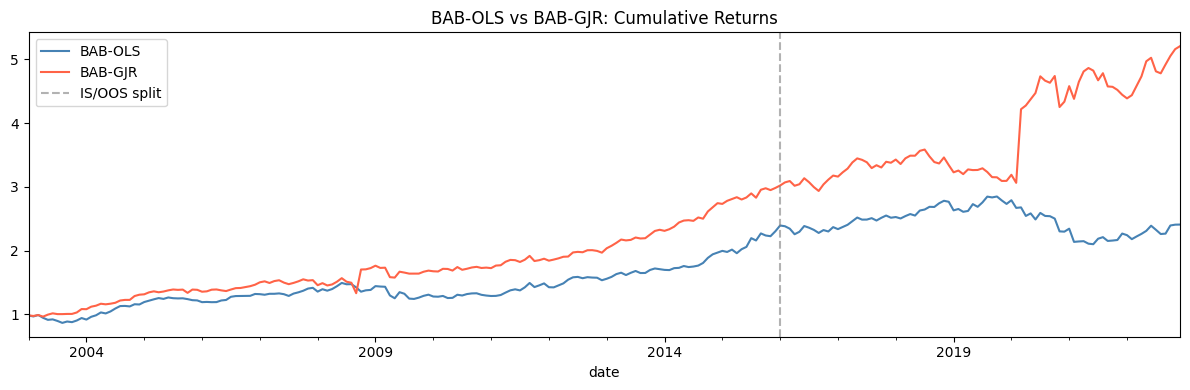

In [ ]:
# Align on common dates
common_idx = df_bab_monthly_ols.index.intersection(df_bab_monthly_gjr.index)

fig, ax = plt.subplots(figsize=(12, 4))
(1 + df_bab_monthly_ols.loc[common_idx, 'r_bab']).cumprod().plot(
    ax=ax, label='BAB-OLS', color='steelblue', linewidth=1.5)
(1 + df_bab_monthly_gjr.loc[common_idx, 'r_bab']).cumprod().plot(
    ax=ax, label='BAB-GJR', color='tomato', linewidth=1.5)
ax.axvline(pd.Timestamp(OOS_START), color='gray', linestyle='--', alpha=0.6, label='IS/OOS split')
ax.set_title('BAB-OLS vs BAB-GJR: Cumulative Returns')
ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
# Side-by-side metrics table (gross and net of transaction costs)
def metrics_row(returns, label):
    ann_ret = returns.mean() * 12
    ann_vol = returns.std()  * np.sqrt(12)
    sharpe  = ann_ret / ann_vol
    return pd.Series({'Ann. Return': f'{ann_ret:.2%}', 'Ann. Vol': f'{ann_vol:.2%}', 'Sharpe': f'{sharpe:.2f}'}, name=label)

IS_END_ols    = '2015-12-31'
OOS_START_ols = '2016-01-01'
df_ols_tmp    = df_bab_monthly_ols.copy()
df_ols_tmp['date'] = pd.to_datetime(df_ols_tmp['yyyymm'].astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
df_ols_tmp = df_ols_tmp.set_index('date').sort_index()

rows = []
for col, tag in [('r_bab', 'Gross'), ('r_bab_net', 'Net')]:
    # OLS
    rows.append(metrics_row(df_ols_tmp[col].dropna(),                                         f'OLS | Full | {tag}'))
    rows.append(metrics_row(df_ols_tmp.loc[:IS_END_ols,    col].dropna(),                     f'OLS | IS   | {tag}'))
    rows.append(metrics_row(df_ols_tmp.loc[OOS_START_ols:, col].dropna(),                     f'OLS | OOS  | {tag}'))
    # GJR
    rows.append(metrics_row(df_bab_monthly_gjr[col].dropna(),                                 f'GJR | Full | {tag}'))
    rows.append(metrics_row(df_bab_monthly_gjr.loc[:'2015-12-31',    col].dropna(),           f'GJR | IS   | {tag}'))
    rows.append(metrics_row(df_bab_monthly_gjr.loc['2016-01-01':,    col].dropna(),           f'GJR | OOS  | {tag}'))

display(pd.DataFrame(rows))

,Ann. Return,Ann. Vol,Sharpe
OLS | Full | Gross,4.78%,8.70%,0.55
OLS | IS | Gross,6.79%,8.50%,0.80
OLS | OOS | Gross,1.05%,9.00%,0.12
GJR | Full | Gross,11.55%,14.60%,0.79
GJR | IS | Gross,12.61%,13.47%,0.94
GJR | OOS | Gross,9.20%,16.90%,0.54
OLS | Full | Net,4.64%,8.70%,0.53
OLS | IS | Net,6.66%,8.50%,0.78
OLS | OOS | Net,0.89%,9.01%,0.10
GJR | Full | Net,10.69%,14.62%,0.73


### 3.2 Performance evaluation

In [ ]:
# Build df_strategies from base BAB portfolios
sr_bab_ols = df_bab_monthly_ols.set_index('yyyymm')['r_bab']
sr_bab_gjr = df_bab_monthly_gjr.reset_index().set_index('yyyymm')['r_bab']

df_strategies = pd.DataFrame({
    'bab_ols' : sr_bab_ols,
    'bab_gjr' : sr_bab_gjr,
}).dropna(how='any')

print(f"df_strategies: {df_strategies.shape}  |  {df_strategies.index[0]} → {df_strategies.index[-1]}")

df_strategies: (240, 2)  |  200301 → 202212


In [ ]:
#  Merge FF3 + IS/OOS split
IS_END_YYYYMM    = int(pd.Timestamp(IS_END).strftime('%Y%m'))
OOS_START_YYYYMM = int(pd.Timestamp(OOS_START).strftime('%Y%m'))

df_eval = (
    df_strategies.reset_index()
    .merge(df_ff3[['yyyymm', 'Mkt-RF', 'SMB', 'HML', 'RF']], on='yyyymm', how='left')
)
df_is  = df_eval[df_eval['yyyymm'] <= IS_END_YYYYMM]
df_oos = df_eval[df_eval['yyyymm'] >= OOS_START_YYYYMM]
print(f"Full: {len(df_eval)}  |  IS: {len(df_is)}  |  OOS: {len(df_oos)}")

Full: 240  |  IS: 156  |  OOS: 84


In [ ]:
# Performance summary table
STRATEGIES = ['bab_ols', 'bab_gjr']
LABELS     = ['BAB-OLS', 'BAB-GJR']
PERIODS    = [('Full', df_eval), ('IS', df_is), ('OOS', df_oos)]

def perf_row(r):
    r       = r.dropna()
    ann_ret = r.mean() * 12
    ann_vol = r.std()  * np.sqrt(12)
    cum     = (1 + r).cumprod()
    return {
        'Ann. Ret' : f'{ann_ret:.2%}',
        'Ann. Vol' : f'{ann_vol:.2%}',
        'Sharpe'   : f'{ann_ret / ann_vol:.2f}',
        'Max DD'   : f'{(cum / cum.cummax() - 1).min():.2%}',
        'Skew'     : f'{r.skew():.2f}',
        'Kurt'     : f'{r.kurtosis():.2f}',
        'CVaR 5%'  : f'{r[r <= r.quantile(0.05)].mean():.2%}',
    }

display(pd.DataFrame(
    {f'{lbl} | {p}': perf_row(df[strat])
     for p, df in PERIODS
     for strat, lbl in zip(STRATEGIES, LABELS)}
).T)


,Ann. Ret,Ann. Vol,Sharpe,Max DD,Skew,Kurt,CVaR 5%
BAB-OLS | Full,4.78%,8.70%,0.55,-26.24%,-0.54,1.45,-5.66%
BAB-GJR | Full,9.05%,13.15%,0.69,-15.02%,5.08,47.69,-5.56%
BAB-OLS | IS,6.79%,8.50%,0.80,-16.79%,-0.42,1.40,-5.05%
BAB-GJR | IS,8.96%,10.66%,0.84,-15.02%,3.89,39.79,-5.13%
BAB-OLS | OOS,1.05%,9.00%,0.12,-26.24%,-0.73,1.51,-6.20%
BAB-GJR | OOS,9.20%,16.90%,0.54,-14.55%,5.15,39.84,-5.43%


In [ ]:
# CAPM and FF3 regressions
def reg_row(df, strat, factors):
    d   = df[['RF', strat] + factors].dropna()
    y   = d[strat] - d['RF']
    res = sm.OLS(y, sm.add_constant(d[factors])).fit(
              cov_type='HAC', cov_kwds={'maxlags': 6})
    return {
        'Alpha'  : f'{res.params["const"]:.4f}',
        't-stat' : f'{res.tvalues["const"]:.2f}',
        'R²'     : f'{res.rsquared:.3f}',
    }

for model, factors in [('CAPM', ['Mkt-RF']), ('FF3', ['Mkt-RF', 'SMB', 'HML'])]:
    print(f'\n{model} Alpha (IS / OOS):')
    display(pd.DataFrame(
        {f'{lbl} | {p}': reg_row(df, strat, factors)
         for p, df in [('IS', df_is), ('OOS', df_oos)]
         for strat, lbl in zip(STRATEGIES, LABELS)}
    ).T)



CAPM Alpha (IS / OOS):


,Alpha,t-stat,R²
BAB-OLS | IS,0.0055,2.50,0.042
BAB-GJR | IS,0.0073,3.36,0.026
BAB-OLS | OOS,0.0012,0.52,0.052
BAB-GJR | OOS,0.0096,1.40,0.085



FF3 Alpha (IS / OOS):


,Alpha,t-stat,R²
BAB-OLS | IS,0.0052,2.39,0.197
BAB-GJR | IS,0.0070,3.04,0.070
BAB-OLS | OOS,0.0006,0.23,0.185
BAB-GJR | OOS,0.0092,1.54,0.162


In [ ]:
# Jobson-Korkie test (OOS only)
# H0: SR_A = SR_B  —  tests whether GJR/VM improvement is statistically significant


def jobson_korkie(r_a, r_b):
    r_a, r_b = r_a.dropna(), r_b.dropna()
    T        = len(r_a)
    sr_a     = r_a.mean() / r_a.std()
    sr_b     = r_b.mean() / r_b.std()
    rho      = np.corrcoef(r_a, r_b)[0, 1]
    var      = (1/T) * (2*(1 - rho**2) + 0.5*(sr_a**2 + sr_b**2) - rho*sr_a*sr_b)
    z        = (sr_a - sr_b) / np.sqrt(max(var, 1e-10))
    p        = 2 * (1 - stats.norm.cdf(abs(z)))
    return {
        'SR_A (ann)' : f'{sr_a * np.sqrt(12):.3f}',
        'SR_B (ann)' : f'{sr_b * np.sqrt(12):.3f}',
        'z-stat'     : f'{z:.3f}',
        'p-value'    : f'{p:.3f}',
    }

jk_tests = {
    'BAB-GJR vs BAB-OLS' : ('bab_gjr', 'bab_ols'),
}

print("Jobson-Korkie Test (OOS only):")
display(pd.DataFrame(
    {lbl: jobson_korkie(df_oos[a], df_oos[b]) for lbl, (a, b) in jk_tests.items()}
).T)


Jobson-Korkie Test (OOS only):


,SR_A (ann),SR_B (ann),z-stat,p-value
BAB-GJR vs BAB-OLS,0.545,0.116,0.838,0.402


## 3.3 Figures

In [ ]:
#Shared setup
df_plot = df_strategies.copy()
df_plot.index = (
    pd.to_datetime(df_plot.index.astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
)
IS_END_DT    = pd.Timestamp(IS_END)
OOS_START_DT = pd.Timestamp(OOS_START)

COLORS = {
    'bab_ols' : 'steelblue',
    'bab_gjr' : 'darkorange',
}
LABELS = {
    'bab_ols' : 'BAB-OLS',
    'bab_gjr' : 'BAB-GJR',
}


def shade_is(ax):
    ax.axvspan(df_plot.index[0], IS_END_DT, alpha=0.12, color='grey', label='IS period')
    ax.axvline(OOS_START_DT, color='black', linestyle='--', linewidth=0.8, alpha=0.6)


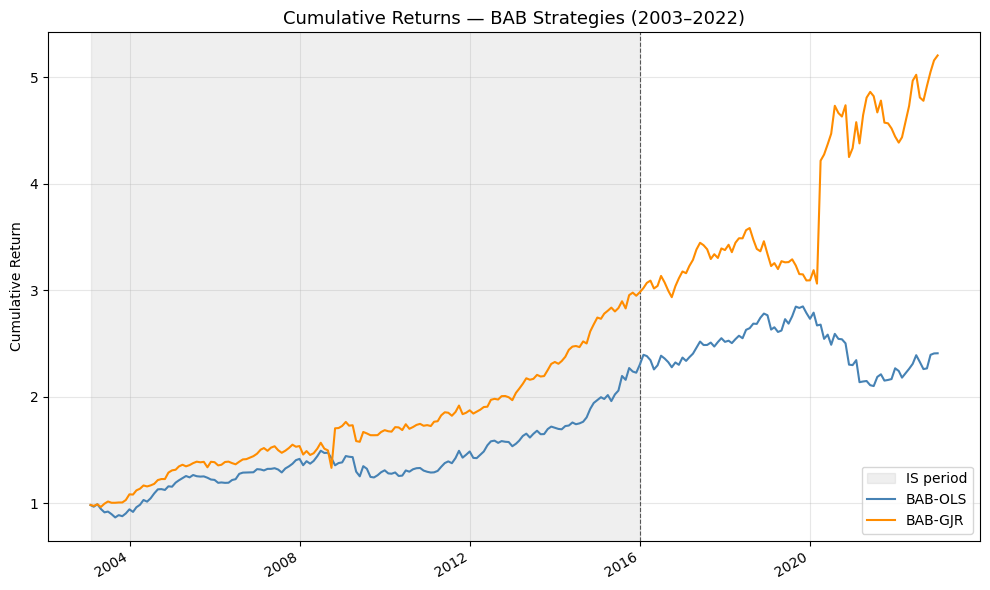

In [ ]:
# Cumulative returns
fig, ax = plt.subplots(figsize=(10, 6))
shade_is(ax)
for strat, lbl in LABELS.items():
    (1 + df_plot[strat]).cumprod().plot(ax=ax, label=lbl, color=COLORS[strat], linewidth=1.5)
ax.set_title('Cumulative Returns — BAB Strategies (2003–2022)', fontsize=13)
ax.set_ylabel('Cumulative Return'); ax.set_xlabel('')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('fig_11_1_cumulative_returns.pdf'); plt.show()


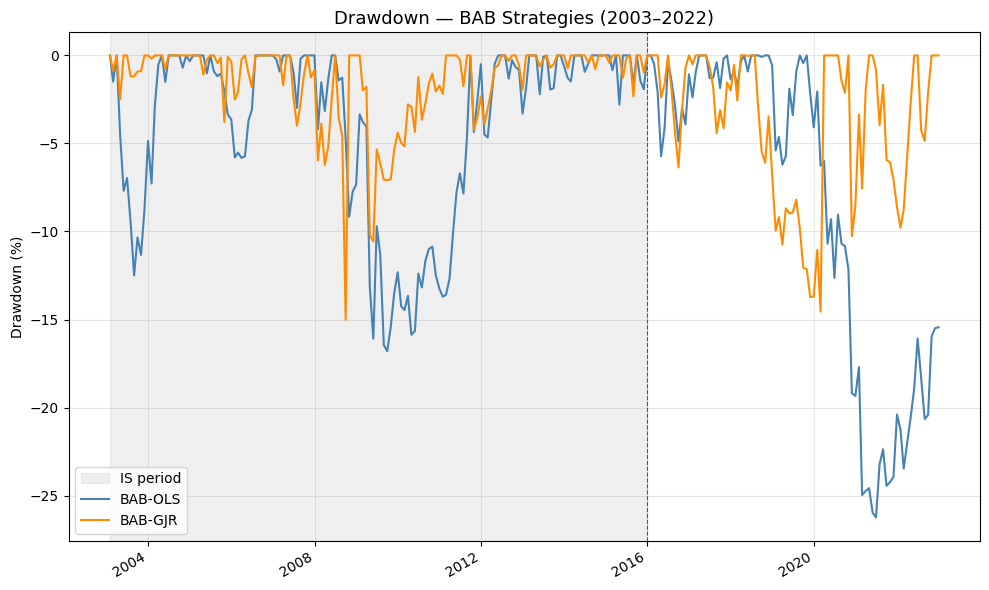

In [ ]:
# Drawdown
def drawdown(r):
    cum = (1 + r).cumprod()
    return (cum / cum.cummax() - 1) * 100

fig, ax = plt.subplots(figsize=(10, 6))
shade_is(ax)
for strat, lbl in LABELS.items():
    drawdown(df_plot[strat]).plot(ax=ax, label=lbl, color=COLORS[strat], linewidth=1.5)
ax.set_title('Drawdown — BAB Strategies (2003–2022)', fontsize=13)
ax.set_ylabel('Drawdown (%)'); ax.set_xlabel('')
ax.legend(loc='lower left'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('fig_11_2_drawdown.pdf'); plt.show()


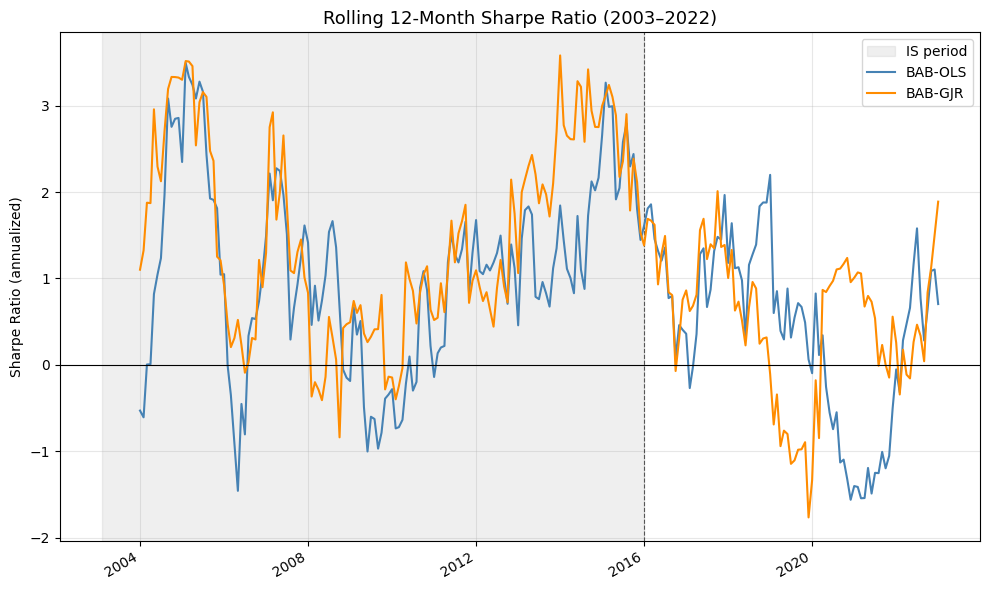

In [ ]:
# Rolling 12-month Sharpe
fig, ax = plt.subplots(figsize=(10, 6))
shade_is(ax)
for strat, lbl in LABELS.items():
    r  = df_plot[strat]
    sr = (r.rolling(12).mean() / r.rolling(12).std()) * np.sqrt(12)
    sr.plot(ax=ax, label=lbl, color=COLORS[strat], linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Rolling 12-Month Sharpe Ratio (2003–2022)', fontsize=13)
ax.set_ylabel('Sharpe Ratio (annualized)'); ax.set_xlabel('')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('fig_11_3_rolling_sharpe.pdf'); plt.show()


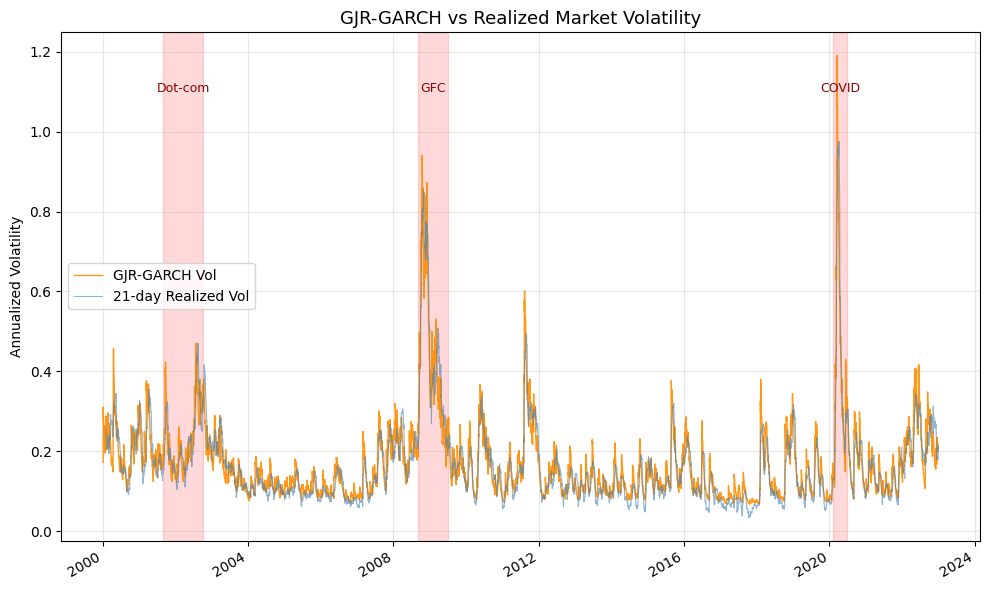

In [ ]:
# GJR-GARCH vol vs realized market vol
gjr_ann      = gjr_mkt_vol * np.sqrt(252)
realized_vol = df_market['log_mkt'].rolling(21).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(10, 6))
gjr_ann.plot(     ax=ax, label='GJR-GARCH Vol',      color='darkorange', linewidth=1.0, alpha=0.9)
realized_vol.plot(ax=ax, label='21-day Realized Vol', color='steelblue',  linewidth=0.8, alpha=0.6)

for label, (s, e) in {
    'Dot-com' : ('2001-09-01', '2002-09-30'),
    'GFC'     : ('2008-09-01', '2009-06-30'),
    'COVID'   : ('2020-02-01', '2020-06-30'),
}.items():
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.15, color='red')
    mid = pd.Timestamp(s) + (pd.Timestamp(e) - pd.Timestamp(s)) / 2
    ax.text(mid, ax.get_ylim()[1] * 0.88, label, ha='center', fontsize=9, color='darkred')

ax.set_title('GJR-GARCH vs Realized Market Volatility', fontsize=13)
ax.set_ylabel('Annualized Volatility'); ax.set_xlabel('')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('fig_11_4_gjr_vol.pdf'); plt.show()


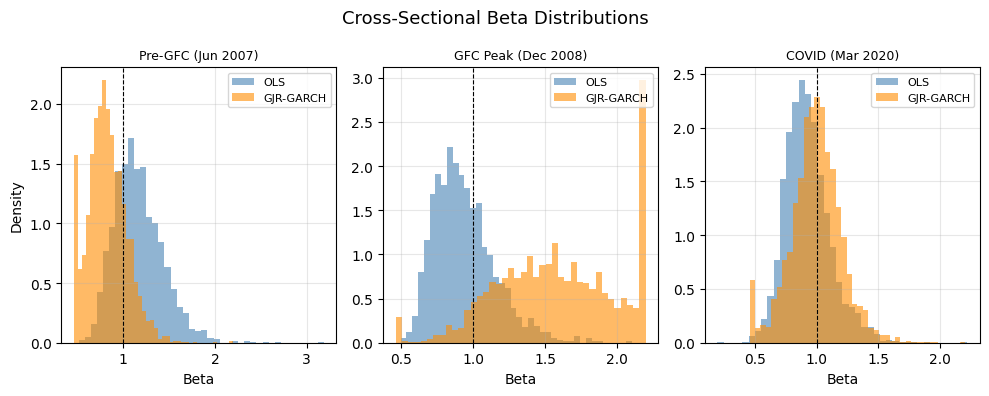

In [ ]:
# Cross-sectional beta distributions at 3 dates
DATES   = [200706,              200812,           202003          ]
DLABELS = ['Pre-GFC (Jun 2007)', 'GFC Peak (Dec 2008)', 'COVID (Mar 2020)']

fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=False)
for ax, yyyymm, lbl in zip(axes, DATES, DLABELS):
    d = df_monthly[df_monthly['yyyymm'] == yyyymm]
    ax.hist(d['beta_ols'].dropna(),  bins=40, alpha=0.6, color='steelblue',  label='OLS',      density=True)
    ax.hist(d['beta_cond'].dropna(), bins=40, alpha=0.6, color='darkorange', label='GJR-GARCH', density=True)
    ax.axvline(1, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(lbl, fontsize=9); ax.set_xlabel('Beta'); ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Density')
fig.suptitle('Cross-Sectional Beta Distributions', fontsize=13)
plt.tight_layout(); plt.savefig('fig_11_5_beta_dist.pdf'); plt.show()


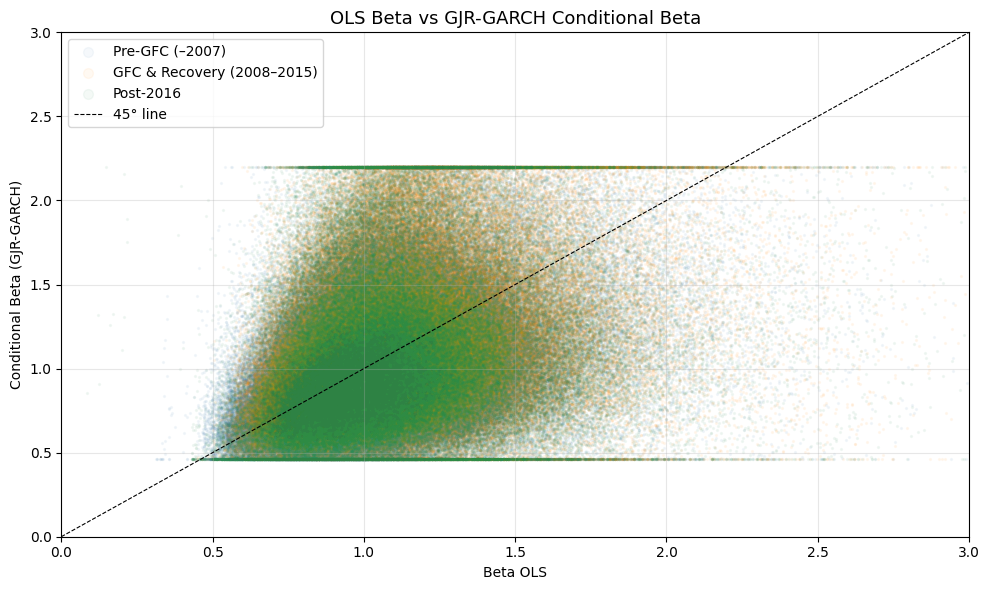

In [ ]:
# Scatter beta_ols vs beta_cond colored by regime
REGIMES = {
    'Pre-GFC (–2007)'          : (0,      200800),
    'GFC & Recovery (2008–2015)': (200800, 201600),
    'Post-2016'                 : (201600, 999999),
}
REGIME_COLORS = ['steelblue', 'darkorange', 'seagreen']

df_sc = df_monthly[['beta_ols', 'beta_cond', 'yyyymm']].dropna()

fig, ax = plt.subplots(figsize=(10, 6))
for (regime, (lo, hi)), color in zip(REGIMES.items(), REGIME_COLORS):
    d = df_sc[(df_sc['yyyymm'] > lo) & (df_sc['yyyymm'] < hi)]
    ax.scatter(d['beta_ols'], d['beta_cond'], alpha=0.05, s=2, color=color, label=regime)
lim = 3
ax.plot([0, lim], [0, lim], 'k--', linewidth=0.8, label='45° line')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_title('OLS Beta vs GJR-GARCH Conditional Beta', fontsize=13)
ax.set_xlabel('Beta OLS'); ax.set_ylabel('Conditional Beta (GJR-GARCH)')
ax.legend(markerscale=5); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('fig_11_6_beta_scatter.pdf'); plt.show()


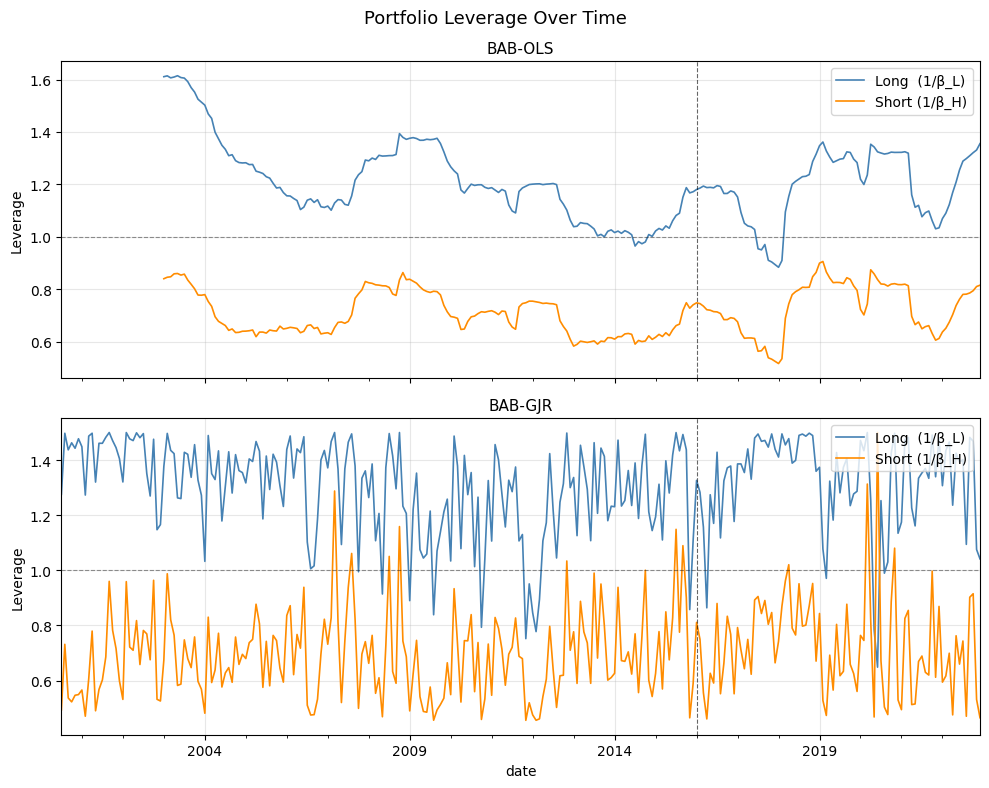

In [ ]:
# Portfolio leverage evolution
df_ols_lev = df_bab_monthly_ols.assign(
    date=pd.to_datetime(df_bab_monthly_ols['yyyymm'].astype(str), format='%Y%m')
         + pd.offsets.MonthEnd(0)
).set_index('date')

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for ax, df_lev, title in [
    (axes[0], df_ols_lev,         'BAB-OLS'),
    (axes[1], df_bab_monthly_gjr, 'BAB-GJR'),
]:
    (1 / df_lev['beta_long'] ).plot(ax=ax, label='Long  (1/β_L)', color='steelblue',  linewidth=1.2)
    (1 / df_lev['beta_short']).plot(ax=ax, label='Short (1/β_H)', color='darkorange', linewidth=1.2)
    ax.axhline(1,           color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.axvline(OOS_START_DT, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.set_title(title, fontsize=11); ax.set_ylabel('Leverage')
    ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)
fig.suptitle('Portfolio Leverage Over Time', fontsize=13)
plt.tight_layout(); plt.savefig('fig_11_7_leverage.pdf'); plt.show()
